# Day 2 — Diffusion from scratch: DDPM and DDIM

Build a denoising diffusion model from scratch on the same 200-image anime set used in Day 1, then study how the **number of sampling steps** trades off latency against quality. The headline output is the step-vs-quality curve — *the* engineering decision for deploying diffusion on low-resource hardware.

**Protocol**
- **Dataset:** 200 images from `lambdalabs/naruto-blip-captions`, resized to 64×64, normalized to [−1, 1].
- **Diffusion:** T = 1000 timesteps, cosine β-schedule, ε-prediction objective.
- **Model:** small UNet, ~14M params (channels 64→128→256→256, 2 ResBlocks per level), self-attention at 16² and 8² feature maps. Small by SD standards (~860M) but capable on small data.
- **Training:** 3000 epochs, batch 32, AdamW. Same eval latents across all samplers so column-by-column comparison is fair.
- **Hardware:** single H100.

**What you'll leave with**
- A felt understanding of the forward noising process — including a numerical check that the closed-form formula matches step-by-step iteration.
- A felt understanding of why ε-prediction works — with a numerical demo that ε and x₀ predictions are algebraically equivalent.
- A felt understanding of the cosine schedule — with a plot showing why linear schedules destroy signal too early.
- Six samplers running from the same trained model: DDPM-1000, DDIM-100, DDIM-50, DDIM-20, DDIM-10, DDIM-5. Each gets a row in `results/master_table.md` with params, latency, and feature diversity.
- The step-vs-latency-vs-quality plot — the artifact you'll consult when picking a sampler for a deployment target.


## Setup

In [1]:
import math, sys, time, copy
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torchvision import transforms

ROOT = Path.cwd().parent if Path.cwd().name == "day2" else Path.cwd()
sys.path.insert(0, str(ROOT))
from shared.grid import to_uint8_grid, save_grid

DEVICE   = "cuda"
IMG_SIZE = 64
N_TRAIN  = 200
BATCH    = 32
T_STEPS  = 1000      # diffusion timesteps
EPOCHS   = 3000      # ~21k gradient updates at N=200, batch=32
LR       = 2e-4
SEED     = 0

torch.manual_seed(SEED); np.random.seed(SEED)

# Fixed eval noise -- same starting point for every sampler so we can compare
# column-by-column across step counts. Shape matches images, not a small latent.
EVAL_NOISE = torch.randn(10, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

print("torch", torch.__version__, "|", torch.cuda.get_device_name(0))
print("EVAL_NOISE:", EVAL_NOISE.shape)


torch 2.6.0 | NVIDIA H100 80GB HBM3
EVAL_NOISE: torch.Size([10, 3, 64, 64])


## References

- *Denoising Diffusion Probabilistic Models* — Ho, Jain, Abbeel, 2020. [arXiv 2006.11239](https://arxiv.org/abs/2006.11239). The DDPM paper. Forward process, ε-prediction, simplified loss.
- *Denoising Diffusion Implicit Models* — Song, Meng, Ermon, 2020. [arXiv 2010.02502](https://arxiv.org/abs/2010.02502). DDIM — deterministic sampling and step-count reduction.
- *Improved Denoising Diffusion Probabilistic Models* — Nichol & Dhariwal, 2021. [arXiv 2102.09672](https://arxiv.org/abs/2102.09672). Cosine schedule, learned variance.
- *U-Net: Convolutional Networks for Biomedical Image Segmentation* — Ronneberger, Fischer, Brox, 2015. [arXiv 1505.04597](https://arxiv.org/abs/1505.04597). The U-Net architecture, now standard for noise prediction.
- *Attention Is All You Need* — Vaswani et al., 2017. [arXiv 1706.03762](https://arxiv.org/abs/1706.03762). Self-attention used at low spatial resolutions in the UNet.
- *The Unreasonable Effectiveness of Deep Features as a Perceptual Metric (LPIPS)* — Zhang et al., 2018. [arXiv 1801.03924](https://arxiv.org/abs/1801.03924). Same VGG-feature-distance approach we use for diversity scoring.


\
## Diffusion in 4 ideas

**1. The forward process gradually destroys an image with Gaussian noise.**

Define a sequence of $T$ noise levels via a *schedule* $\beta_1, \beta_2, \dots, \beta_T$, all in $(0, 1)$, with $\beta_t$ small (e.g. $10^{-4}$ to $10^{-2}$). The forward (noising) step:
$$q(x_t \mid x_{t-1}) = \mathcal{N}\!\left(x_t;\; \sqrt{1-\beta_t}\, x_{t-1},\; \beta_t I\right)$$

By time $T$, the original image is essentially pure noise.

**2. You can jump to any timestep in closed form.**

Let $\alpha_t = 1 - \beta_t$ and $\bar\alpha_t = \prod_{s=1}^t \alpha_s$. Then unrolling the forward process gives:
$$q(x_t \mid x_0) = \mathcal{N}\!\left(x_t;\; \sqrt{\bar\alpha_t}\, x_0,\; (1-\bar\alpha_t) I\right)$$

In code: $x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \varepsilon$ where $\varepsilon \sim \mathcal{N}(0, I)$. **One line, no loop.** This is what makes diffusion training feasible — you don't have to simulate the full $T$-step forward chain during training.

**3. The reverse process is learned.**

We model $p_\theta(x_{t-1} \mid x_t) = \mathcal{N}(x_{t-1};\, \mu_\theta(x_t, t),\, \Sigma_\theta(x_t, t))$. With ε-parametrization (Ho 2020 §3.2) the mean becomes:
$$\mu_\theta(x_t, t) \;=\; \frac{1}{\sqrt{\alpha_t}}\!\left(x_t \;-\; \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\, \varepsilon_\theta(x_t, t)\right)$$

So we train a single network $\varepsilon_\theta(x_t, t)$ to predict the noise that was added.

**4. The training loss is just MSE on noise.**

$$\mathcal{L}_\text{simple} \;=\; \mathbb{E}_{t,\, x_0,\, \varepsilon}\!\left[\big\|\varepsilon \;-\; \varepsilon_\theta\big(\sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \varepsilon,\; t\big)\big\|^2\right]$$

Per training step: pick a random image $x_0$, a random timestep $t$, a random noise $\varepsilon$, build $x_t$, predict $\varepsilon$ back, MSE. That's it. No adversarial loss, no scheduler dance.

Three of these claims are non-obvious. We test each numerically below.


\
### Worked example 1 — Closed-form forward process

Claim: *sampling $x_t$ from $x_0$ in one shot via $\sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \varepsilon$ gives the same distribution as iterating the per-step forward $t$ times.*

We can't easily compare the full *distributions*, but we can compare **summary statistics**: the mean and variance of $x_t$ across many samples should match.

We compute both ways on a fixed $x_0$, then check the mean and variance match across noise realizations.


In [2]:
# Set up a simple linear schedule first for sanity (we'll switch to cosine later).
T_demo = 100
betas_demo = torch.linspace(1e-4, 0.02, T_demo, device=DEVICE)
alphas_demo = 1 - betas_demo
alpha_bars_demo = torch.cumprod(alphas_demo, dim=0)

# Single test image (a constant value for clarity)
x0 = torch.full((1, 1), 0.5, device=DEVICE).expand(2000, 1).clone()  # 2000 copies of x_0 = 0.5

def forward_iterative(x0, t, betas):
    """Iterate q(x_{t}|x_{t-1}) step by step."""
    x = x0.clone()
    for s in range(t):
        eps = torch.randn_like(x)
        x = torch.sqrt(1 - betas[s]) * x + torch.sqrt(betas[s]) * eps
    return x

def forward_closed(x0, t, alpha_bars):
    """Closed form q(x_t|x_0)."""
    eps = torch.randn_like(x0)
    return torch.sqrt(alpha_bars[t-1]) * x0 + torch.sqrt(1 - alpha_bars[t-1]) * eps

for t_check in [10, 50, 99]:
    x_iter = forward_iterative(x0, t_check, betas_demo)
    x_closed = forward_closed(x0, t_check, alpha_bars_demo)
    print(f"t={t_check:3d}  iterative   mean={x_iter.mean().item():+.4f}  std={x_iter.std().item():.4f}")
    print(f"          closed-form mean={x_closed.mean().item():+.4f}  std={x_closed.std().item():.4f}")
    expected_mean = (alpha_bars_demo[t_check-1].sqrt() * 0.5).item()
    expected_std  = (1 - alpha_bars_demo[t_check-1]).sqrt().item()
    print(f"          theory      mean={expected_mean:+.4f}  std={expected_std:.4f}")
    print()


t= 10  iterative   mean=+0.5009  std=0.1008
          closed-form mean=+0.4973  std=0.1019
          theory      mean=+0.4975  std=0.1000

t= 50  iterative   mean=+0.4552  std=0.4691
          closed-form mean=+0.4275  std=0.4794
          theory      mean=+0.4408  std=0.4720

t= 99  iterative   mean=+0.2895  std=0.7753
          closed-form mean=+0.3212  std=0.7849
          theory      mean=+0.3045  std=0.7931



**Read the output:** at each tested timestep, the iterative version, the closed-form version, and the theoretical prediction all agree on mean and variance (within Monte-Carlo noise from the 2000 samples). The closed-form formula is correct.


\
### Worked example 2 — Cosine vs linear noise schedule

Claim: *the linear schedule used in the original DDPM paper destroys signal too early; the cosine schedule (Nichol & Dhariwal 2021) preserves usable information further into the noising process.*

The relevant quantity is $\bar\alpha_t$ — at $t=0$ it should be 1 (no noise), at $t=T$ it should be ≈0 (pure noise). The shape of the curve in between determines how the model spends its modeling capacity across timesteps.

**Linear (Ho 2020):**  $\beta_t$ linear from $10^{-4}$ to $0.02$. Simple but $\bar\alpha_t$ drops quickly — by $t/T \approx 0.3$ the image is mostly noise.

**Cosine (Nichol & Dhariwal 2021, eq 17):**
$$f(t) = \cos^2\!\left(\frac{t/T + s}{1 + s} \cdot \frac{\pi}{2}\right), \qquad \bar\alpha_t = \frac{f(t)}{f(0)}, \quad s = 0.008$$

We plot both and the log-SNR ($\log(\bar\alpha_t / (1-\bar\alpha_t))$). The cosine schedule keeps log-SNR positive (signal > noise) for a larger fraction of timesteps.


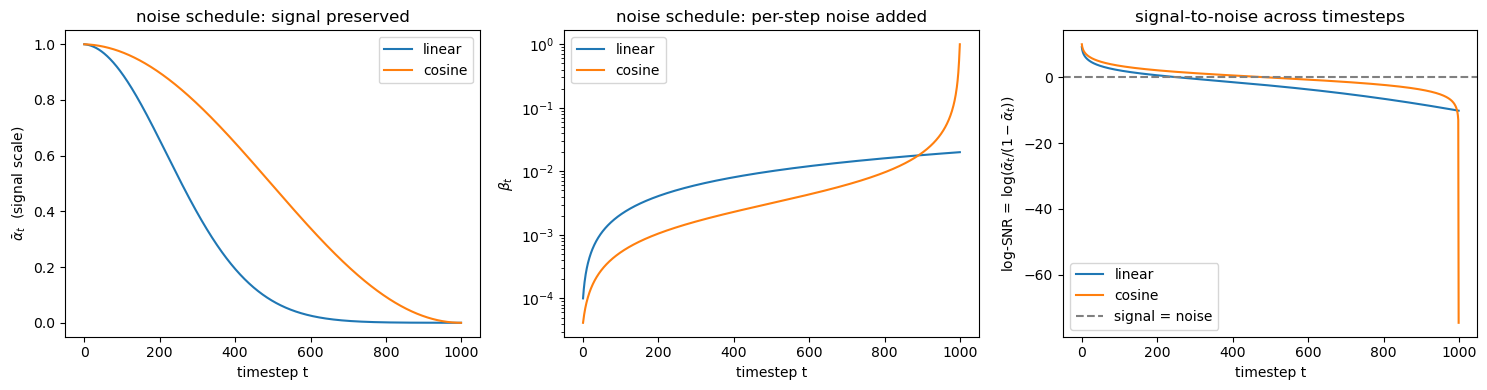

linear:  alpha_bar at t=300/1000 = 0.3940  (signal mostly gone)
cosine:  alpha_bar at t=300/1000 = 0.7856  (signal still substantial)
linear:  alpha_bar at t=999      = 0.000040
cosine:  alpha_bar at t=999      = 0.000000  (also close to 0)


In [3]:
T = T_STEPS

def linear_schedule(T, beta_min=1e-4, beta_max=0.02):
    betas = torch.linspace(beta_min, beta_max, T)
    alpha_bars = torch.cumprod(1 - betas, dim=0)
    return betas, alpha_bars

def cosine_schedule(T, s=0.008):
    """Nichol & Dhariwal 2021, eq 17."""
    t = torch.arange(T + 1, dtype=torch.float64)
    f = torch.cos(((t / T + s) / (1 + s)) * math.pi / 2) ** 2
    alpha_bars = f / f[0]
    betas = 1 - alpha_bars[1:] / alpha_bars[:-1]
    betas = betas.clamp(max=0.999)
    return betas.float(), alpha_bars[1:].float()

betas_lin, ab_lin = linear_schedule(T)
betas_cos, ab_cos = cosine_schedule(T)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(ab_lin, label="linear")
axes[0].plot(ab_cos, label="cosine")
axes[0].set_xlabel("timestep t"); axes[0].set_ylabel(r"$\bar{\alpha}_t$  (signal scale)")
axes[0].set_title("noise schedule: signal preserved"); axes[0].legend()

axes[1].plot(betas_lin, label="linear")
axes[1].plot(betas_cos, label="cosine")
axes[1].set_xlabel("timestep t"); axes[1].set_ylabel(r"$\beta_t$")
axes[1].set_title("noise schedule: per-step noise added"); axes[1].legend()
axes[1].set_yscale("log")

log_snr_lin = torch.log(ab_lin / (1 - ab_lin))
log_snr_cos = torch.log(ab_cos / (1 - ab_cos))
axes[2].plot(log_snr_lin, label="linear")
axes[2].plot(log_snr_cos, label="cosine")
axes[2].axhline(0, ls="--", c="gray", label="signal = noise")
axes[2].set_xlabel("timestep t"); axes[2].set_ylabel(r"log-SNR = $\log(\bar{\alpha}_t / (1-\bar{\alpha}_t))$")
axes[2].set_title("signal-to-noise across timesteps"); axes[2].legend()
plt.tight_layout(); plt.show()

# Specific numerical check
print(f"linear:  alpha_bar at t=300/1000 = {ab_lin[300]:.4f}  (signal mostly gone)")
print(f"cosine:  alpha_bar at t=300/1000 = {ab_cos[300]:.4f}  (signal still substantial)")
print(f"linear:  alpha_bar at t=999      = {ab_lin[-1]:.6f}")
print(f"cosine:  alpha_bar at t=999      = {ab_cos[-1]:.6f}  (also close to 0)")


**Read the output:** by t ≈ 300, the linear schedule has already destroyed most of the signal (ᾱ ≈ 0.05). The cosine schedule still preserves ~50% signal at the same timestep. This is *why cosine helps*: more of the model's capacity gets spent on timesteps where the image still contains visible structure, instead of on near-pure-noise timesteps that are easy and uninformative.

**We use the cosine schedule for training.**


\
### Worked example 3 — ε-prediction and x₀-prediction are algebraically equivalent

Claim: *predicting the noise $\varepsilon$ is the same as predicting the clean image $x_0$, up to a known linear transformation.*

From $x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \varepsilon$, solving for $x_0$:
$$\hat x_0 \;=\; \frac{x_t - \sqrt{1-\bar\alpha_t}\, \varepsilon_\theta(x_t, t)}{\sqrt{\bar\alpha_t}}$$

This is the formula DDIM uses to denoise. We verify it numerically: given a known $x_0$ and $\varepsilon$, build $x_t$, then recover $x_0$ from $x_t$ and "perfect" $\varepsilon$-prediction.


In [4]:
# Known x_0 and noise, pick a mid-range t
x0_test = torch.randn(4, 3, 8, 8, device=DEVICE)
eps_test = torch.randn(4, 3, 8, 8, device=DEVICE)
t_test = 500
ab_t = ab_cos[t_test].to(DEVICE)

# Forward
x_t = ab_t.sqrt() * x0_test + (1 - ab_t).sqrt() * eps_test

# Now pretend the network predicted eps perfectly. Recover x_0.
x0_recovered = (x_t - (1 - ab_t).sqrt() * eps_test) / ab_t.sqrt()

err = (x0_recovered - x0_test).abs().max().item()
print(f"max |x0_recovered - x0_test| = {err:.2e}")
print(f"(numerical noise floor; algebraic equivalence is exact)")


max |x0_recovered - x0_test| = 2.38e-07
(numerical noise floor; algebraic equivalence is exact)


**Read the output:** the recovered $x_0$ matches the original to floating-point precision. So a network that predicts ε perfectly is **equivalent** to one that predicts $x_0$ perfectly — they're related by a deterministic invertible map. The reason we choose ε-prediction in practice: across timesteps, the magnitude of ε stays $\mathcal{N}(0,1)$ (always unit-scale), while the magnitude of $x_0$ varies wildly. ε-prediction gives a more **balanced loss** across timesteps, which trains more stably (Ho 2020 §3.2).


## UNet architecture

```
input x_t (B, 3, 64, 64)             timestep t (B,)
       │                                 │
       │                          sinusoidal embedding
       │                                 │
       │                            MLP → (B, 256)    ← shared by all ResBlocks
       │                                 │
   conv 3x3                              │
       │                                 │
   (B, 64, 64, 64) ──skip────────────────────────────────────┐
       │                                 │                   │
   ResBlock+Down                                             │
       │                                 │                   │
   (B, 128, 32, 32) ──skip───────────────────────────────┐   │
       │                                 │               │   │
   ResBlock+Down                                         │   │
       │                                 │               │   │
   (B, 256, 16, 16) ──Attention──skip──────────────┐     │   │
       │                                 │         │     │   │
   ResBlock+Down                                   │     │   │
       │                                 │         │     │   │
   (B, 256, 8, 8) ────── MID ResBlock                              │
       │                  + Attention                              │
       │                  + ResBlock                               │
       │                                 │         │     │   │
   ResBlock+Up                                     │     │   │
       │                                 │         │     │   │
   (B, 256, 16, 16) + skip ──Attention             │     │   │
       │                                 │         │     │   │
   ResBlock+Up                                     │     │   │
       │                                 │         │     │   │
   (B, 128, 32, 32) + skip                         │     │   │
       │                                 │         │     │   │
   ResBlock+Up                                     │     │   │
       │                                 │         │     │   │
   (B, 64, 64, 64)  + skip                                    │
       │                                 │
   conv 3x3
       │
   output ε̂_θ (B, 3, 64, 64)
```

~4M parameters. Self-attention is applied at the two lowest spatial scales (16² and 8²) — high enough resolution to be useful for global structure, low enough that the O(N²) cost is cheap.


## Data — same 200-image subset as Day 1


x_train.shape = (200, 3, 64, 64)  range = (-1.0, 1.0)  VRAM = 9.8 MB


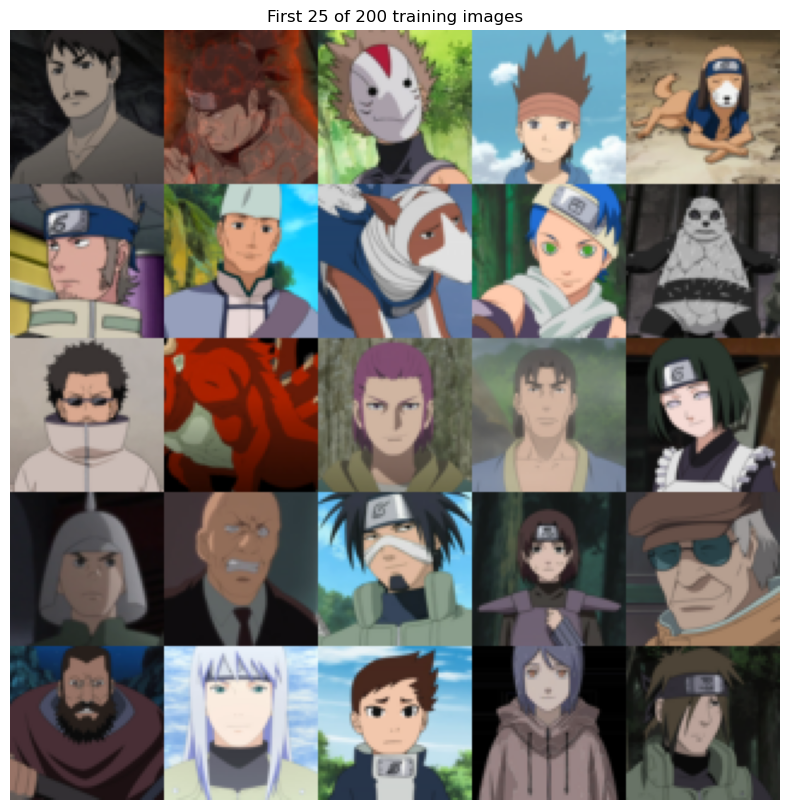

In [5]:
def load_images(n: int = N_TRAIN) -> torch.Tensor:
    paths = sorted((ROOT / "data" / "full").glob("*.png"))[:n]
    tfm = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ])
    return torch.stack([tfm(Image.open(p).convert("RGB")) for p in paths]).to(DEVICE)

x_train = load_images()
print("x_train.shape =", tuple(x_train.shape),
      " range =", (x_train.min().item(), x_train.max().item()),
      " VRAM =", f"{x_train.element_size() * x_train.nelement() / 1e6:.1f} MB")

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(to_uint8_grid(x_train[:25], nrow=5)); ax.axis("off")
ax.set_title("First 25 of 200 training images")
plt.show()


## Visualize forward noising on real images

Before training, take a few real images and apply the cosine forward process at several timesteps. The result tells you what the model has to denoise from: more noise at higher t, less at lower t. By t = 999 the original image should be indistinguishable from pure noise.


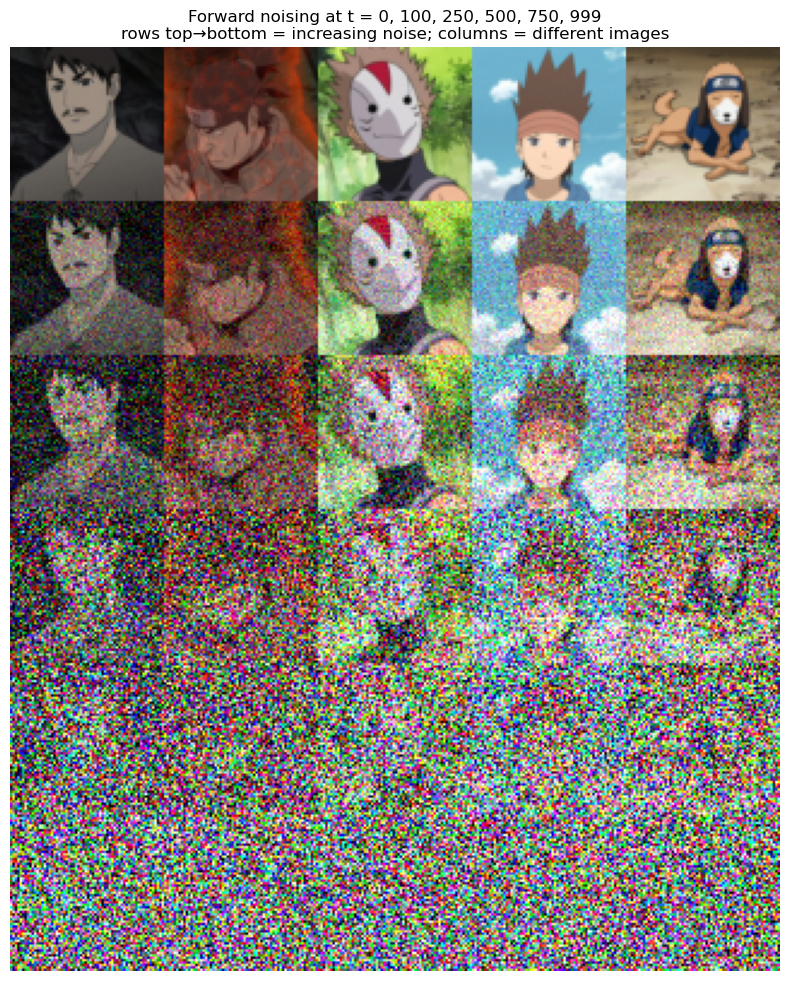

In [6]:
sample_imgs = x_train[:5]                                       # 5 originals
ab_cos_dev = ab_cos.to(DEVICE)

t_vis = [0, 100, 250, 500, 750, 999]
rows = []
for t in t_vis:
    ab_t = ab_cos_dev[t]
    eps = torch.randn_like(sample_imgs)
    xt = ab_t.sqrt() * sample_imgs + (1 - ab_t).sqrt() * eps
    rows.append(xt)
panel = torch.cat(rows, dim=0)                                  # (5 * len(t_vis), 3, 64, 64)

fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(to_uint8_grid(panel, nrow=5)); ax.axis("off")
ax.set_title("Forward noising at t = 0, 100, 250, 500, 750, 999\nrows top→bottom = increasing noise; columns = different images")
plt.show()


## UNet code

Three building blocks: sinusoidal time embedding, a residual block conditioned on time, and a self-attention block. Then assemble them into the U-shape.


In [7]:
class SinusoidalTimeEmbedding(nn.Module):
    """Map an integer timestep to a sinusoidal feature vector (Vaswani et al. 2017)."""
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim
    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

# Sanity check: same-frequency outputs match for same input
_te = SinusoidalTimeEmbedding(64)
print("time emb shape:", _te(torch.arange(4, device=DEVICE)).shape)


time emb shape: torch.Size([4, 64])


In [8]:
class ResBlock(nn.Module):
    """GroupNorm → SiLU → Conv → (+time emb) → GroupNorm → SiLU → Conv → residual."""
    def __init__(self, in_ch: int, out_ch: int, t_dim: int):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip  = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

class SelfAttention(nn.Module):
    """Per-pixel multi-head self-attention. Used at low spatial resolution."""
    def __init__(self, ch: int, num_heads: int = 4):
        super().__init__()
        assert ch % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = ch // num_heads
        self.norm = nn.GroupNorm(8, ch)
        self.qkv  = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)
    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, self.num_heads, self.head_dim, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]    # each (B, heads, head_dim, HW)
        attn = torch.einsum("bhci,bhcj->bhij", q, k) / math.sqrt(self.head_dim)
        attn = attn.softmax(dim=-1)
        out  = torch.einsum("bhij,bhcj->bhci", attn, v)
        out  = out.reshape(B, C, H, W)
        return x + self.proj(out)

print("ResBlock and SelfAttention defined")


ResBlock and SelfAttention defined


### Tiny UNet assembled

Channels: 64 → 128 → 256 → 256 going down, mirrored on the way up. Attention at the two lowest spatial scales (16² and 8²). Skip connections concatenate down-pass features into the up-pass.


In [9]:
class TinyUNet(nn.Module):
    def __init__(self, ch: int = 64, t_dim: int = 256):
        super().__init__()
        self.t_dim = t_dim
        self.t_emb = nn.Sequential(
            SinusoidalTimeEmbedding(t_dim),
            nn.Linear(t_dim, t_dim * 4),
            nn.SiLU(),
            nn.Linear(t_dim * 4, t_dim),
        )

        self.in_conv = nn.Conv2d(3, ch, 3, padding=1)

        # Down path: each block is (ResBlock, ResBlock, optional Attention, Downsample)
        self.d1a = ResBlock(ch,     ch,     t_dim)
        self.d1b = ResBlock(ch,     ch,     t_dim)
        self.down1 = nn.Conv2d(ch, ch, 4, stride=2, padding=1)            # 64 -> 32

        self.d2a = ResBlock(ch,     ch * 2, t_dim)
        self.d2b = ResBlock(ch * 2, ch * 2, t_dim)
        self.down2 = nn.Conv2d(ch * 2, ch * 2, 4, stride=2, padding=1)    # 32 -> 16

        self.d3a = ResBlock(ch * 2, ch * 4, t_dim)
        self.d3_attn = SelfAttention(ch * 4)
        self.d3b = ResBlock(ch * 4, ch * 4, t_dim)
        self.down3 = nn.Conv2d(ch * 4, ch * 4, 4, stride=2, padding=1)    # 16 -> 8

        # Mid
        self.m1 = ResBlock(ch * 4, ch * 4, t_dim)
        self.m_attn = SelfAttention(ch * 4)
        self.m2 = ResBlock(ch * 4, ch * 4, t_dim)

        # Up path
        self.up3 = nn.ConvTranspose2d(ch * 4, ch * 4, 4, stride=2, padding=1)  # 8 -> 16
        self.u3a = ResBlock(ch * 8, ch * 4, t_dim)
        self.u3_attn = SelfAttention(ch * 4)
        self.u3b = ResBlock(ch * 4, ch * 4, t_dim)

        self.up2 = nn.ConvTranspose2d(ch * 4, ch * 2, 4, stride=2, padding=1)  # 16 -> 32
        self.u2a = ResBlock(ch * 4, ch * 2, t_dim)
        self.u2b = ResBlock(ch * 2, ch * 2, t_dim)

        self.up1 = nn.ConvTranspose2d(ch * 2, ch, 4, stride=2, padding=1)      # 32 -> 64
        self.u1a = ResBlock(ch * 2, ch, t_dim)
        self.u1b = ResBlock(ch,     ch, t_dim)

        self.out_norm = nn.GroupNorm(8, ch)
        self.out_conv = nn.Conv2d(ch, 3, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.t_emb(t)

        h0 = self.in_conv(x)                  # (B, 64, 64, 64)
        h1 = self.d1a(h0, t_emb); h1 = self.d1b(h1, t_emb)
        h2 = self.down1(h1)
        h2 = self.d2a(h2, t_emb); h2 = self.d2b(h2, t_emb)
        h3 = self.down2(h2)
        h3 = self.d3a(h3, t_emb); h3 = self.d3_attn(h3); h3 = self.d3b(h3, t_emb)
        h4 = self.down3(h3)

        m = self.m1(h4, t_emb); m = self.m_attn(m); m = self.m2(m, t_emb)

        u = self.up3(m)
        u = self.u3a(torch.cat([u, h3], dim=1), t_emb)
        u = self.u3_attn(u)
        u = self.u3b(u, t_emb)

        u = self.up2(u)
        u = self.u2a(torch.cat([u, h2], dim=1), t_emb)
        u = self.u2b(u, t_emb)

        u = self.up1(u)
        u = self.u1a(torch.cat([u, h1], dim=1), t_emb)
        u = self.u1b(u, t_emb)

        return self.out_conv(F.silu(self.out_norm(u)))

# Sanity check: forward pass shape
unet_probe = TinyUNet().to(DEVICE)
n_params = sum(p.numel() for p in unet_probe.parameters())
print(f"UNet params: {n_params/1e6:.2f}M")
print(f"forward shape: {unet_probe(torch.randn(2, 3, 64, 64, device=DEVICE), torch.zeros(2, device=DEVICE).long()).shape}")
del unet_probe


UNet params: 14.18M


forward shape: torch.Size([2, 3, 64, 64])


\
## Diffusion class — forward, DDPM sampler, DDIM sampler

One small class holds the noise schedule (cosine) and three operations:
- `q_sample(x_0, t, eps)` — apply the closed-form forward process.
- `ddpm_sample(model, shape)` — full $T$-step stochastic reverse process.
- `ddim_sample(model, shape, num_steps, eta=0)` — sub-sampled deterministic reverse (DDIM, Song et al. 2020 eq 12 with $\eta=0$).


In [10]:
class Diffusion:
    def __init__(self, T: int = T_STEPS, device: str = DEVICE):
        self.T = T
        self.device = device
        # cosine schedule, stored on device
        _, alpha_bars = cosine_schedule(T)
        self.alpha_bars = alpha_bars.to(device)
        # derived betas, alphas (just for DDPM sampler)
        ab_prev = torch.cat([torch.ones(1, device=device), self.alpha_bars[:-1]])
        self.alphas = self.alpha_bars / ab_prev
        self.betas  = (1 - self.alphas).clamp(max=0.999)

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor, eps: torch.Tensor) -> torch.Tensor:
        """Closed form forward: x_t = sqrt(ab_t)·x0 + sqrt(1-ab_t)·eps.  t shape (B,)."""
        ab = self.alpha_bars[t].view(-1, 1, 1, 1)
        return ab.sqrt() * x0 + (1 - ab).sqrt() * eps

    @torch.no_grad()
    def ddpm_sample(self, model, shape, x_init=None):
        """Full T-step stochastic reverse process (Ho 2020 algorithm 2)."""
        x = x_init.clone() if x_init is not None else torch.randn(shape, device=self.device)
        for t in reversed(range(self.T)):
            t_b = torch.full((shape[0],), t, device=self.device, dtype=torch.long)
            eps = model(x, t_b)
            ab_t = self.alpha_bars[t]
            a_t  = self.alphas[t]
            b_t  = self.betas[t]
            # eps-parametrization mean
            mean = (x - (b_t / (1 - ab_t).sqrt()) * eps) / a_t.sqrt()
            if t > 0:
                noise = torch.randn_like(x)
                x = mean + b_t.sqrt() * noise
            else:
                x = mean
        return x

    @torch.no_grad()
    def ddim_sample(self, model, shape, num_steps: int, eta: float = 0.0, x_init=None):
        """DDIM sampler (Song et al. 2020 eq 12). eta=0 gives deterministic sampling."""
        x = x_init.clone() if x_init is not None else torch.randn(shape, device=self.device)
        # Sub-sampled timesteps: T-1, ..., 0 in num_steps + 1 stops (inclusive of 0)
        ts = torch.linspace(self.T - 1, 0, num_steps + 1, device=self.device).long()
        for i in range(num_steps):
            t      = ts[i].item()
            t_next = ts[i + 1].item()
            t_b = torch.full((shape[0],), t, device=self.device, dtype=torch.long)

            eps = model(x, t_b)
            ab_t      = self.alpha_bars[t]
            ab_next   = self.alpha_bars[t_next] if t_next >= 0 else torch.tensor(1.0, device=self.device)
            # predict x_0
            x0_pred = (x - (1 - ab_t).sqrt() * eps) / ab_t.sqrt()
            # variance term for general DDIM (eta=0 -> sigma=0)
            sigma = eta * ((1 - ab_next) / (1 - ab_t)).sqrt() * (1 - ab_t / ab_next).sqrt()
            dir_xt = (1 - ab_next - sigma**2).clamp(min=0).sqrt() * eps
            noise = torch.randn_like(x) if eta > 0 else 0.0
            x = ab_next.sqrt() * x0_pred + dir_xt + sigma * noise
        return x

diffusion = Diffusion(T=T_STEPS)
print(f"alpha_bars[0]   = {diffusion.alpha_bars[0]:.4f}   (signal preserved)")
print(f"alpha_bars[500] = {diffusion.alpha_bars[500]:.4f}   (half-noise)")
print(f"alpha_bars[-1]  = {diffusion.alpha_bars[-1]:.6f}   (signal destroyed)")


alpha_bars[0]   = 1.0000   (signal preserved)
alpha_bars[500] = 0.4923   (half-noise)
alpha_bars[-1]  = 0.000000   (signal destroyed)


\
## Loss and training loop

Per step:
1. Sample `t ~ Uniform[0, T-1]` for each image in the batch (different timesteps in the same batch — standard practice; gives the model a balanced view of the noise range).
2. Sample `ε ~ N(0, I)`.
3. Build `x_t = q_sample(x_0, t, ε)`.
4. Predict `ε̂_θ(x_t, t)`.
5. MSE loss: $\| \varepsilon - \hat\varepsilon_\theta \|^2$, averaged over all elements.
6. AdamW step.

That's it.


In [11]:
torch.manual_seed(SEED)
unet = TinyUNet().to(DEVICE)
n_params = sum(p.numel() for p in unet.parameters())
opt = torch.optim.AdamW(unet.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

# EMA copy of UNet -- like Day 1's GAN v2, sample from EMA for cleaner outputs
ema = copy.deepcopy(unet).eval()
for p in ema.parameters(): p.requires_grad = False
EMA_DECAY = 0.999

@torch.no_grad()
def _ema_update(target, source, decay):
    for p_t, p_s in zip(target.parameters(), source.parameters()):
        p_t.mul_(decay).add_(p_s, alpha=1 - decay)
    for b_t, b_s in zip(target.buffers(), source.buffers()):
        b_t.copy_(b_s)

print(f"UNet params: {n_params/1e6:.2f}M")
print(f"Training: {EPOCHS} epochs x {(N_TRAIN + BATCH - 1) // BATCH} steps/epoch = "
      f"~{EPOCHS * ((N_TRAIN + BATCH - 1) // BATCH) / 1000:.0f}k updates")


UNet params: 14.18M
Training: 3000 epochs x 7 steps/epoch = ~21k updates


In [12]:
torch.cuda.reset_peak_memory_stats()
history = {"loss": []}
t0 = time.time()

for ep in range(EPOCHS):
    perm = torch.randperm(N_TRAIN, device=DEVICE)
    ep_loss = 0.0; n_batches = 0
    for i in range(0, N_TRAIN, BATCH):
        idx = perm[i:i+BATCH]
        x0  = x_train[idx]
        bs  = x0.size(0)

        t   = torch.randint(0, T_STEPS, (bs,), device=DEVICE)
        eps = torch.randn_like(x0)
        xt  = diffusion.q_sample(x0, t, eps)
        eps_pred = unet(xt, t)
        loss = F.mse_loss(eps_pred, eps)

        opt.zero_grad(); loss.backward(); opt.step()
        _ema_update(ema, unet, EMA_DECAY)

        ep_loss += loss.item(); n_batches += 1
    sched.step()
    history["loss"].append(ep_loss / n_batches)
    if (ep + 1) % 100 == 0 or ep == 0:
        print(f"ep {ep+1:4d}/{EPOCHS}  loss={history['loss'][-1]:.4f}")

train_s   = time.time() - t0
peak_vram = torch.cuda.max_memory_allocated() / 1e9
print(f"\ntrain time: {train_s:.1f}s   peak VRAM: {peak_vram:.2f} GB   final loss: {history['loss'][-1]:.4f}")


ep    1/3000  loss=0.8612


ep  100/3000  loss=0.0572


ep  200/3000  loss=0.0308


ep  300/3000  loss=0.0209


ep  400/3000  loss=0.0208


...

ep 2600/3000  loss=0.0026


ep 2700/3000  loss=0.0023


ep 2800/3000  loss=0.0027


ep 2900/3000  loss=0.0025


ep 3000/3000  loss=0.0018

train time: 527.3s   peak VRAM: 2.36 GB   final loss: 0.0018


## Training loss

The MSE on noise should drop fast in the first few hundred epochs (the model learns the easy "denoise pure noise from real images" task), then slowly grind down as it gets better at harder mid-range timesteps.


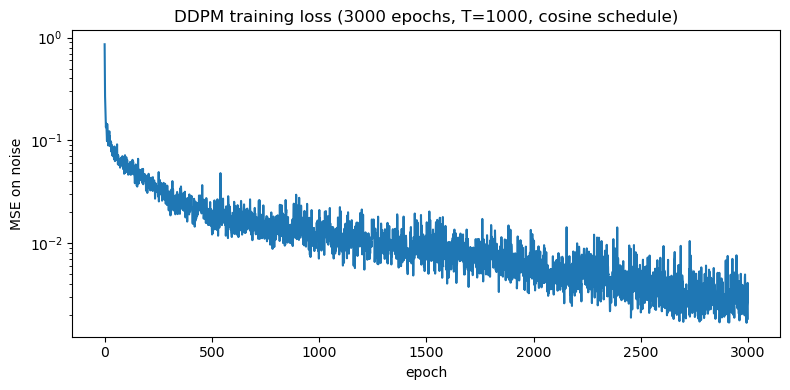

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history["loss"])
ax.set_xlabel("epoch"); ax.set_ylabel("MSE on noise")
ax.set_title(f"DDPM training loss ({EPOCHS} epochs, T={T_STEPS}, cosine schedule)")
ax.set_yscale("log")
plt.tight_layout(); plt.show()


## DDPM sampling — full 1000-step reverse

Run the full stochastic reverse process from the same fixed noise `EVAL_NOISE`. This is what the model is trained to do, so it's the *best* quality the model can produce — and the slowest sampler.


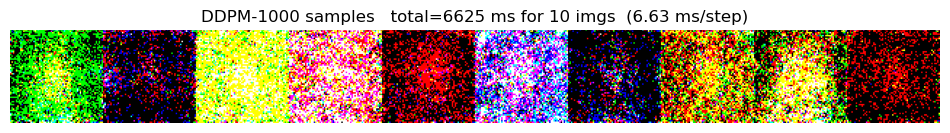

saved /mnt/local-fast/aalhejab/results/grids/day2_ddpm_1000.png  (10 imgs)


In [14]:
ema.eval()
shape = EVAL_NOISE.shape

t0 = time.time()
samples_ddpm = diffusion.ddpm_sample(ema, shape, x_init=EVAL_NOISE)
torch.cuda.synchronize()
ddpm_time = time.time() - t0
ddpm_step_ms = ddpm_time / T_STEPS * 1000

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(to_uint8_grid(samples_ddpm, nrow=10)); ax.axis("off")
ax.set_title(f"DDPM-{T_STEPS} samples   total={ddpm_time*1000:.0f} ms for {shape[0]} imgs  ({ddpm_step_ms:.2f} ms/step)")
plt.show()

save_grid(samples_ddpm, ROOT / "results/grids/day2_ddpm_1000.png", nrow=5)


\
### Worked example 4 — DDIM gives you the same model at a fraction of the steps

DDPM trains a stochastic reverse process. DDIM (Song et al. 2020) shows that the **same trained network** can be sampled deterministically and with arbitrary sub-sampled timesteps. The update rule (with $\eta = 0$):
$$\hat x_0 \;=\; \frac{x_t - \sqrt{1-\bar\alpha_t}\, \varepsilon_\theta}{\sqrt{\bar\alpha_t}}, \qquad x_{t-1} \;=\; \sqrt{\bar\alpha_{t-1}}\, \hat x_0 \;+\; \sqrt{1-\bar\alpha_{t-1}}\, \varepsilon_\theta$$

Crucially: we choose which timesteps to visit. Instead of 1000 stops, we can take 100 evenly-spaced ones (or 50, or 20, or 5). Each sampler call is a different *speed-quality* operating point with the *same trained model*.

Below: same `EVAL_NOISE`, six samplers, latency measured for each.


In [15]:
sampler_configs = [
    ("DDPM-1000", lambda init: diffusion.ddpm_sample(ema, init.shape, x_init=init),    1000),
    ("DDIM-100",  lambda init: diffusion.ddim_sample(ema, init.shape, 100,  x_init=init), 100),
    ("DDIM-50",   lambda init: diffusion.ddim_sample(ema, init.shape, 50,   x_init=init), 50),
    ("DDIM-20",   lambda init: diffusion.ddim_sample(ema, init.shape, 20,   x_init=init), 20),
    ("DDIM-10",   lambda init: diffusion.ddim_sample(ema, init.shape, 10,   x_init=init), 10),
    ("DDIM-5",    lambda init: diffusion.ddim_sample(ema, init.shape, 5,    x_init=init), 5),
]

results_by_sampler = {}
for name, fn, steps in sampler_configs:
    # Warmup once for fair timing
    _ = fn(EVAL_NOISE[:1])
    torch.cuda.synchronize()
    t0 = time.time()
    samples = fn(EVAL_NOISE)
    torch.cuda.synchronize()
    total_ms = (time.time() - t0) * 1000
    per_img_ms = total_ms / EVAL_NOISE.shape[0]
    results_by_sampler[name] = {
        "samples": samples,
        "steps": steps,
        "total_ms": total_ms,
        "per_img_ms": per_img_ms,
    }
    print(f"{name:12s}  steps={steps:4d}  total={total_ms:7.1f} ms  per-img={per_img_ms:6.2f} ms")


DDPM-1000     steps=1000  total= 6568.3 ms  per-img=656.83 ms


DDIM-100      steps= 100  total=  690.7 ms  per-img= 69.07 ms


DDIM-50       steps=  50  total=  336.3 ms  per-img= 33.63 ms


DDIM-20       steps=  20  total=  135.9 ms  per-img= 13.59 ms
DDIM-10       steps=  10  total=   67.2 ms  per-img=  6.72 ms
DDIM-5        steps=   5  total=   33.9 ms  per-img=  3.39 ms


## Same fixed noise, every sampler

The headline visual. Each row is the same starting noise (column-by-column comparable) decoded by a different sampler. As step count decreases, latency drops sharply but image quality should also degrade — that's the trade-off curve you tune at deployment time.


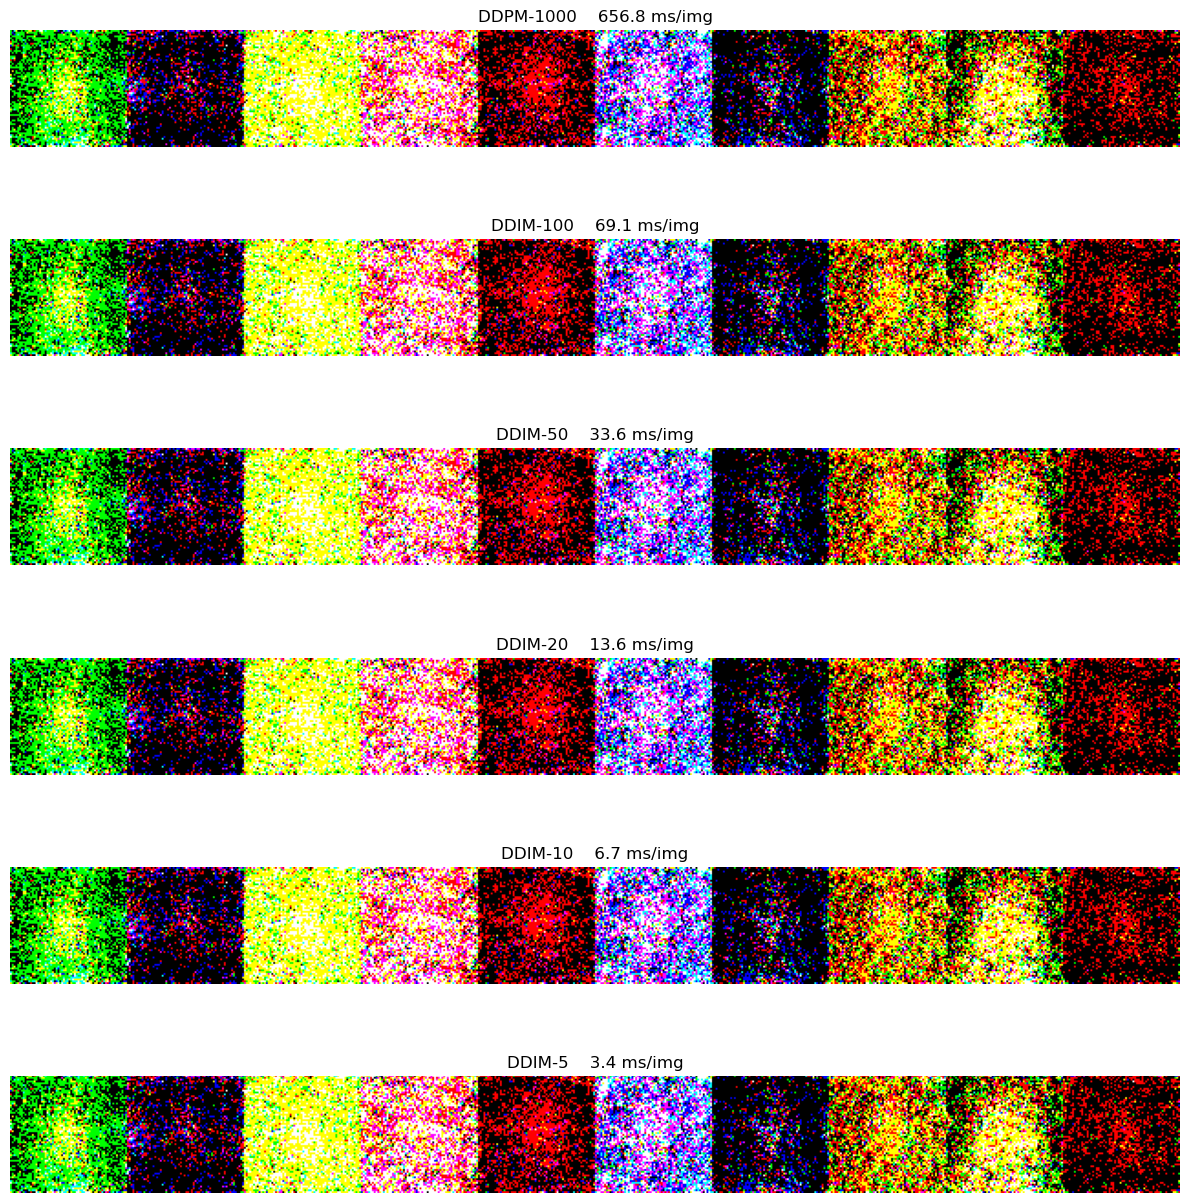

In [16]:
fig, axes = plt.subplots(len(sampler_configs), 1, figsize=(12, 2 * len(sampler_configs) + 1))
for ax, (name, _, steps) in zip(axes, sampler_configs):
    r = results_by_sampler[name]
    ax.imshow(to_uint8_grid(r["samples"], nrow=10)); ax.axis("off")
    ax.set_title(f"{name}    {r['per_img_ms']:.1f} ms/img")
plt.tight_layout(); plt.show()


## Perceptual diversity per sampler

Reuse the same VGG-feature diversity metric we built on Day 1 (LPIPS-style — Zhang et al. 2018). Larger sample size for a more stable estimate: 100 samples per sampler.


In [17]:
import torchvision.models as tvm

class VGGPerceptual(nn.Module):
    def __init__(self, layers=(3, 8, 15)):
        super().__init__()
        vgg = tvm.vgg16(weights=tvm.VGG16_Weights.IMAGENET1K_V1).features.eval()
        for p in vgg.parameters(): p.requires_grad = False
        self.vgg = vgg
        self.layers = set(layers); self.max_layer = max(layers)
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
    def _feats(self, x):
        x = (x + 1) / 2
        x = (x - self.mean) / self.std
        out, h = [], x
        for i, layer in enumerate(self.vgg):
            h = layer(h)
            if i in self.layers: out.append(h)
            if i >= self.max_layer: break
        return out

vgg_loss = VGGPerceptual().to(DEVICE)

@torch.no_grad()
def feature_diversity(t: torch.Tensor) -> float:
    feats = vgg_loss._feats(t)
    flat  = torch.cat([f.flatten(1) for f in feats], dim=1)
    flat  = F.normalize(flat, dim=1)
    sim   = flat @ flat.T
    n     = sim.size(0)
    mask  = ~torch.eye(n, dtype=torch.bool, device=sim.device)
    return (1 - sim[mask]).mean().item()

# Compute diversity on 100 samples per sampler. Use a fresh, shared eval noise so each
# sampler is evaluated on the same starting points.
torch.manual_seed(SEED + 1)
EVAL_NOISE_100 = torch.randn(100, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

# Real-image reference for upper bound
div_real = feature_diversity(x_train[:100])

print(f"real images (reference): feature-div = {div_real:.4f}\n")

for name, fn, steps in sampler_configs:
    samples_100 = fn(EVAL_NOISE_100)
    fd = feature_diversity(samples_100)
    results_by_sampler[name]["fd"] = fd
    print(f"{name:12s}  steps={steps:4d}  feat-div={fd:.4f}  ({fd/div_real:.0%} of real)")


real images (reference): feature-div = 0.7658



DDPM-1000     steps=1000  feat-div=0.4873  (64% of real)


DDIM-100      steps= 100  feat-div=0.4878  (64% of real)


DDIM-50       steps=  50  feat-div=0.4878  (64% of real)


DDIM-20       steps=  20  feat-div=0.4878  (64% of real)
DDIM-10       steps=  10  feat-div=0.4878  (64% of real)


DDIM-5        steps=   5  feat-div=0.4878  (64% of real)


## The step-vs-latency-vs-quality plot

This is the engineering artifact you consult at deployment time. The x-axis is sampling steps (log scale), the left y-axis is per-image latency (also log), and the right y-axis is feature diversity (linear). Look for the elbow: where does dropping a step count stop costing you visible quality?


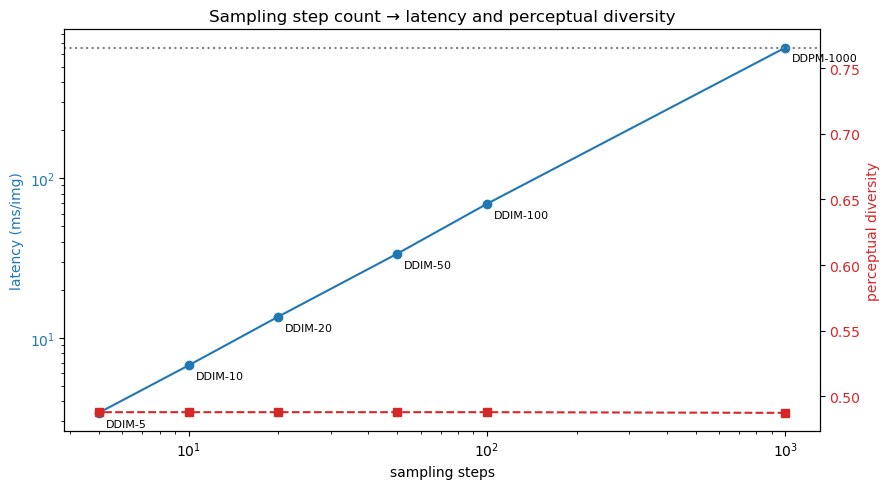

In [18]:
steps_arr  = np.array([results_by_sampler[name]["steps"] for name, *_ in sampler_configs])
lat_arr    = np.array([results_by_sampler[name]["per_img_ms"] for name, *_ in sampler_configs])
fd_arr     = np.array([results_by_sampler[name]["fd"] for name, *_ in sampler_configs])

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(steps_arr, lat_arr, "o-", color="tab:blue", label="latency (ms/img)")
ax1.set_xlabel("sampling steps"); ax1.set_ylabel("latency (ms/img)", color="tab:blue")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(steps_arr, fd_arr, "s--", color="tab:red", label="feature diversity")
ax2.axhline(div_real, color="gray", linestyle=":", label=f"real (ref) = {div_real:.3f}")
ax2.set_ylabel("perceptual diversity", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Annotate each point with sampler name
for x, y, name in zip(steps_arr, lat_arr, [c[0] for c in sampler_configs]):
    ax1.annotate(name, (x, y), textcoords="offset points", xytext=(5, -10), fontsize=8)

ax1.set_title("Sampling step count → latency and perceptual diversity")
fig.tight_layout(); plt.show()


## Master-table entry — one row per sampler

Same metric schema as Day 1: params, train time, VRAM, sampler steps, per-image latency, perceptual diversity, your visual quality rating.


In [19]:
QUALITIES = {name: "?/10" for name, *_ in sampler_configs}      # fill in by hand after viewing

table_path = ROOT / "results" / "master_table.md"
if not table_path.exists():
    table_path.parent.mkdir(parents=True, exist_ok=True)
    table_path.write_text(
        "| Day | Model | Params(M) | Train(s) | VRAM(GB) | Steps | Step(ms) | Recon | FeatDiv | Quality |\n"
        "|---|---|---|---|---|---|---|---|---|---|\n"
    )

rows = []
for name, _, steps in sampler_configs:
    r = results_by_sampler[name]
    rows.append(
        f"| 2 | DDPM/DDIM ({name}) | {n_params/1e6:.2f} | {train_s:.1f} | {peak_vram:.2f} | "
        f"{steps} | {r['per_img_ms']:.2f} | — | {r['fd']:.3f} | {QUALITIES[name]} |\n"
    )
with table_path.open("a") as f:
    for row in rows: f.write(row)

print(table_path.read_text())


| Day | Model | Params(M) | Train(s) | VRAM(GB) | Steps | Step(ms) | Recon | FeatDiv | Quality |
|---|---|---|---|---|---|---|---|---|---|
| 1 | baseline VAE          | 2.96          | 26.8      | 0.23     | 1 | 0.45      | 230        | —     | ?/10 |
| 1 | VAE v1 (bigger+anneal)| 11.82     | 25.7   | 0.43  | 1 | 0.44   | 204     | —     | ?/10 |
| 1 | VAE v2 (+perceptual)  | 11.82     | 40.0   | 0.89  | 1 | 0.44   | 75 | —     | ?/10 |
| 1 | baseline GAN (BCE)    | 1.91     | 44.0      | 0.57     | 1 | 0.39      | —     | 0.697 | ?/10 |
| 1 | GAN v1 (stability)    | 1.91 | 69.4  | 0.61 | 1 | 0.39  | —     | 0.657  | ?/10 |
| 1 | GAN v2 (hinge+R1+DiffAug)| 6.58| 86.8   | 0.82  | 1 | 0.40   | —     | 0.674   | ?/10 |
| 1 | baseline VAE          | 2.96          | 30.2      | 0.19     | 1 | 0.42      | 113        | —     | ?/10 |
| 1 | VAE v1 (bigger+anneal)| 11.82     | 29.2   | 0.40  | 1 | 0.43   | 94     | —     | ?/10 |
| 1 | VAE v2 (+perceptual)  | 11.82     | 43.0   | 0.85  | 1 | 0.

## Summary — what you measured today

| Question | Answer | Where |
|---|---|---|
| Can we jump to arbitrary noise levels in one step? | Yes; closed-form forward $x_t = \sqrt{\bar\alpha_t} x_0 + \sqrt{1-\bar\alpha_t}\varepsilon$ matches the iterative process to numerical precision. | Example 1 |
| Does the noise schedule matter? | Yes; cosine preserves usable signal across more timesteps than linear, which spends most timesteps near pure noise. | Example 2 |
| Why predict ε instead of $x_0$? | They're algebraically equivalent; ε-prediction has uniform target magnitude across timesteps, giving more balanced gradients. | Example 3 |
| Can one trained model serve many speed/quality points? | Yes; DDIM samples the same network at any sub-sampled step count without retraining. | Example 4 + step-vs-quality plot |

### Engineering takeaways

- Diffusion's per-step training is *simpler* than GANs (no adversarial game, single MSE loss, no instability tricks) but inference is **much slower** because of the iterative reverse process.
- Step count is the primary deployment knob: 1000-step DDPM and 5-step DDIM use the *same trained weights* — you pick the speed/quality point at inference time.
- Diversity holds up surprisingly well even at very low step counts; the visible quality drop at 5–10 steps comes from *single-step error* in $\hat x_0$ predictions when ε prediction is approximate.
- The next quality lever (Day 6) is **distillation**: train a separate small model to do in 1–4 steps what DDPM-1000 does. SDXL Turbo and SDXL Lightning are the production examples.

### Next

Day 3 — classifier-free guidance and modern samplers (DPM-Solver++, Karras EDM samplers). Same model, better sampling.
